# Klasyfikacja obrazow kart - CNN z optymalizacja, augmentacja i transfer learning

Dataset: Cards Image Dataset (Kaggle)

Zadania:
- Klasyfikacja kart do 53 klas
- Eksperymentowanie z rozna architektura CNN
- Optymalizacja hyperparametrow
- Augmentacja danych
- Transfer learning (VGG16, VGG19, ResNet50, InceptionV3, MobileNetV2, EfficientNetB0)
- Wizualizacje: filtry, mapy aktywacji, Grad-CAM, confusion matrix
- Zapisywanie checkpointow

https://www.kaggle.com/datasets/gpiosenka/cards-image-datasetclassification

## 1. Importy i konfiguracja

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2
import json
from pathlib import Path

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array
from tensorflow.keras.models import Sequential, Model, load_model
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Flatten, Dropout, 
    BatchNormalization, GlobalAveragePooling2D, Input
)
from tensorflow.keras.optimizers import Adam, RMSprop, SGD
from tensorflow.keras.callbacks import (
    ModelCheckpoint, EarlyStopping, ReduceLROnPlateau, CSVLogger
)
from tensorflow.keras.applications import (
    VGG16, VGG19, ResNet50, InceptionV3, MobileNetV2, EfficientNetB0
)

from sklearn.metrics import confusion_matrix, classification_report

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")

# Konfiguracja
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('husl')
np.random.seed(42)
tf.random.set_seed(42)

2026-03-30 21:49:44.150578: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-30 21:49:44.385851: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: SSE4.1 SSE4.2 AVX AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow version: 2.20.0
GPU available: []


## 2. Konfiguracja sciezek i parametrow

In [2]:
# Sciezki - dostosuj do swojego srodowiska
BASE_DIR = Path.cwd()
DATA_DIR = BASE_DIR / '../data/cards-image-datasetclassification'
TRAIN_DIR = DATA_DIR / 'train'
VALID_DIR = DATA_DIR / 'valid'
TEST_DIR = DATA_DIR / 'test'

# Utworz katalogi na wyniki
RESULTS_DIR = BASE_DIR / 'results'
CHECKPOINTS_DIR = RESULTS_DIR / 'checkpoints'
PLOTS_DIR = RESULTS_DIR / 'plots'
LOGS_DIR = RESULTS_DIR / 'logs'

for directory in [RESULTS_DIR, CHECKPOINTS_DIR, PLOTS_DIR, LOGS_DIR]:
    directory.mkdir(exist_ok=True, parents=True)

print(f"Base directory: {BASE_DIR}")
print(f"Data directory: {DATA_DIR}")
print(f"Results directory: {RESULTS_DIR}")

# Sprawdz czy dane istnieja
if TRAIN_DIR.exists():
    classes = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
    print(f"\nNumber of classes: {len(classes)}")
    print(f"Sample classes: {classes[:5]}")
else:
    print(f"\nWARNING: Training directory not found at {TRAIN_DIR}")
    print("Please download dataset from Kaggle and adjust DATA_DIR path")

Base directory: /home/chemik/projects/ggsn/ex2
Data directory: /home/chemik/projects/ggsn/ex2/../data/cards-image-datasetclassification
Results directory: /home/chemik/projects/ggsn/ex2/results

Number of classes: 53
Sample classes: ['ace of clubs', 'ace of diamonds', 'ace of hearts', 'ace of spades', 'eight of clubs']


In [3]:
# Parametry obrazow
IMG_HEIGHT = 224
IMG_WIDTH = 224
IMG_CHANNELS = 3
IMG_SIZE = (IMG_HEIGHT, IMG_WIDTH)

# Parametry treningu
BATCH_SIZE = 32
EPOCHS = 50
LEARNING_RATE = 0.001

# Liczba klas
if TRAIN_DIR.exists():
    NUM_CLASSES = len([d for d in TRAIN_DIR.iterdir() if d.is_dir()])
else:
    NUM_CLASSES = 53  # dla datasetu kart

print(f"Image size: {IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Number of classes: {NUM_CLASSES}")

Image size: (224, 224)
Batch size: 32
Number of classes: 53


## 3. Eksploracja danych

Dataset statistics:
Total training images: 7624
Images per class - min: 108, max: 181, mean: 143.8


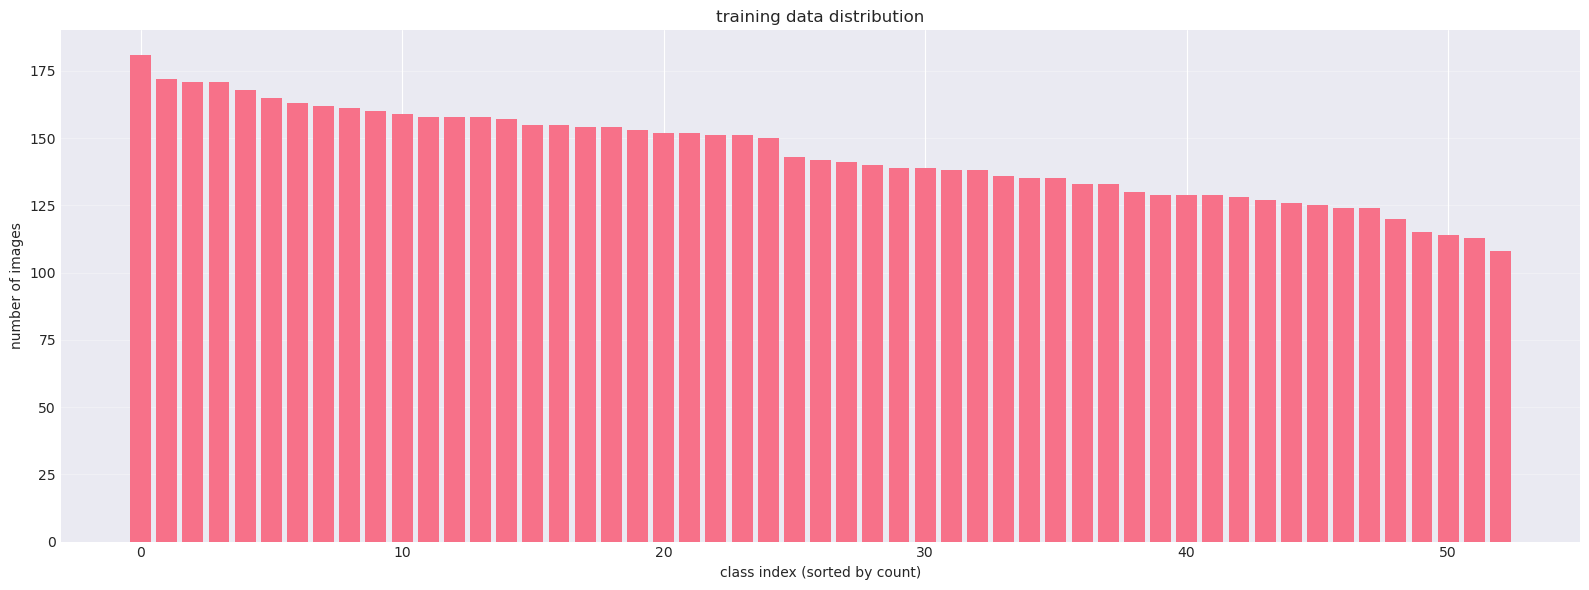

In [4]:
# Analiza struktury datasetu
if TRAIN_DIR.exists():
    train_counts = {}
    for class_dir in TRAIN_DIR.iterdir():
        if class_dir.is_dir():
            count = len(list(class_dir.glob('*.jpg'))) + len(list(class_dir.glob('*.png')))
            train_counts[class_dir.name] = count
    
    print("Dataset statistics:")
    print(f"Total training images: {sum(train_counts.values())}")
    print(f"Images per class - min: {min(train_counts.values())}, max: {max(train_counts.values())}, mean: {np.mean(list(train_counts.values())):.1f}")
    
    # Wizualizacja rozkladu klas
    plt.figure(figsize=(16, 6))
    plt.bar(range(len(train_counts)), sorted(train_counts.values(), reverse=True))
    plt.xlabel('class index (sorted by count)')
    plt.ylabel('number of images')
    plt.title('training data distribution')
    plt.grid(axis='y', alpha=0.3)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'data_distribution.png', dpi=150, bbox_inches='tight')
    plt.show()

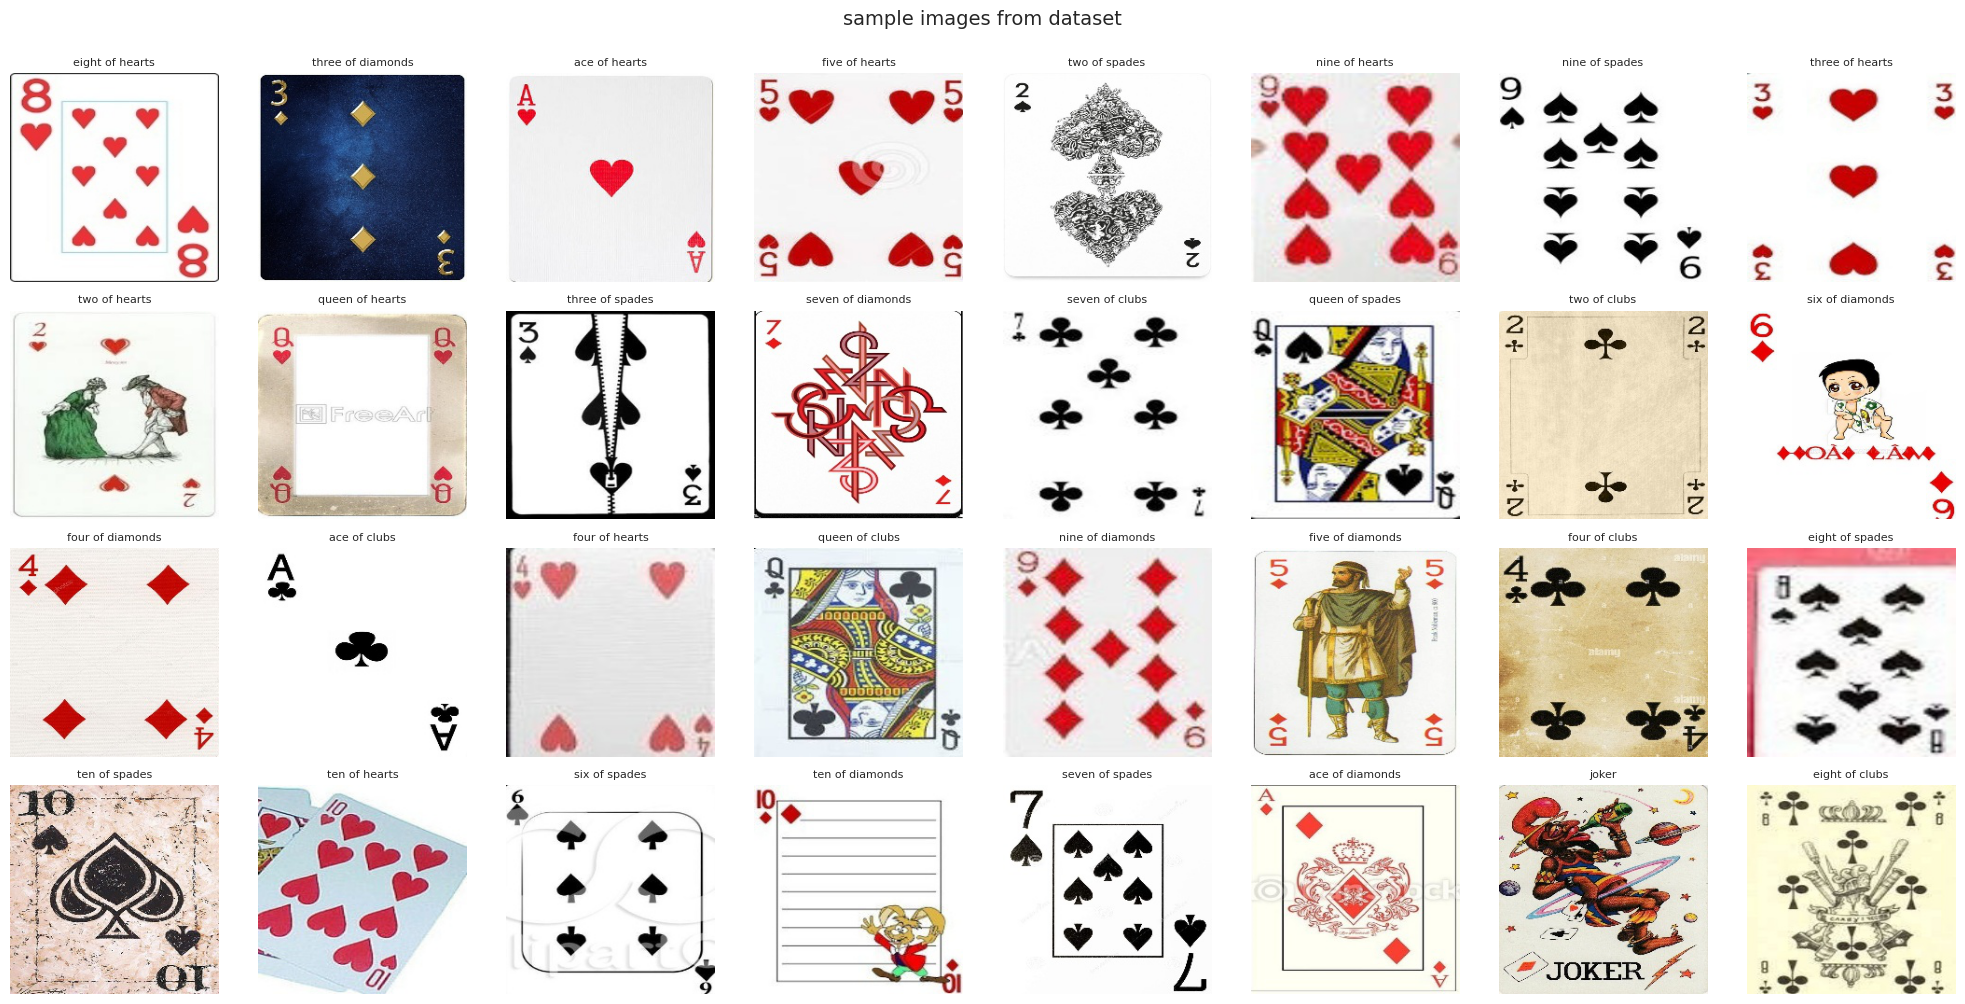

In [5]:
# Wyswietl przykladowe obrazy
if TRAIN_DIR.exists():
    fig, axes = plt.subplots(4, 8, figsize=(20, 10))
    axes = axes.ravel()
    
    class_dirs = [d for d in TRAIN_DIR.iterdir() if d.is_dir()]
    sample_classes = np.random.choice(class_dirs, size=min(32, len(class_dirs)), replace=False)
    
    for idx, class_dir in enumerate(sample_classes):
        images = list(class_dir.glob('*.jpg')) + list(class_dir.glob('*.png'))
        if images:
            img_path = np.random.choice(images)
            img = load_img(img_path, target_size=IMG_SIZE)
            axes[idx].imshow(img)
            axes[idx].set_title(class_dir.name, fontsize=8)
            axes[idx].axis('off')
    
    plt.suptitle('sample images from dataset', fontsize=14, y=1.00)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'sample_images.png', dpi=150, bbox_inches='tight')
    plt.show()

## 4. Przygotowanie generatorow danych

In [6]:
# Generator bez augmentacji (baseline)
train_datagen_baseline = ImageDataGenerator(
    rescale=1./255
)

# Generator z augmentacja
train_datagen_augmented = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.15,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Generator walidacyjny i testowy
valid_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

print("Data generators created")

Data generators created


In [7]:
# Utworz generatory flow_from_directory
if TRAIN_DIR.exists():
    train_generator_baseline = train_datagen_baseline.flow_from_directory(
        TRAIN_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True,
        seed=42
    )
    
    train_generator_augmented = train_datagen_augmented.flow_from_directory(
        TRAIN_DIR,
        target_size=IMG_SIZE,
        batch_size=BATCH_SIZE,
        class_mode='categorical',
        shuffle=True,
        seed=42
    )
    
    if VALID_DIR.exists():
        valid_generator = valid_datagen.flow_from_directory(
            VALID_DIR,
            target_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            class_mode='categorical',
            shuffle=False
        )
    
    if TEST_DIR.exists():
        test_generator = test_datagen.flow_from_directory(
            TEST_DIR,
            target_size=IMG_SIZE,
            batch_size=BATCH_SIZE,
            class_mode='categorical',
            shuffle=False
        )
    
    # Zapisz mapowanie klas
    class_indices = train_generator_baseline.class_indices
    with open(RESULTS_DIR / 'class_indices.json', 'w') as f:
        json.dump(class_indices, f, indent=2)
    
    print(f"\nClass indices saved to {RESULTS_DIR / 'class_indices.json'}")
    print(f"Total classes: {len(class_indices)}")
else:
    print("Data directories not found. Please adjust paths.")

Found 7624 images belonging to 53 classes.
Found 7624 images belonging to 53 classes.
Found 265 images belonging to 53 classes.
Found 265 images belonging to 53 classes.

Class indices saved to /home/chemik/projects/ggsn/ex2/results/class_indices.json
Total classes: 53


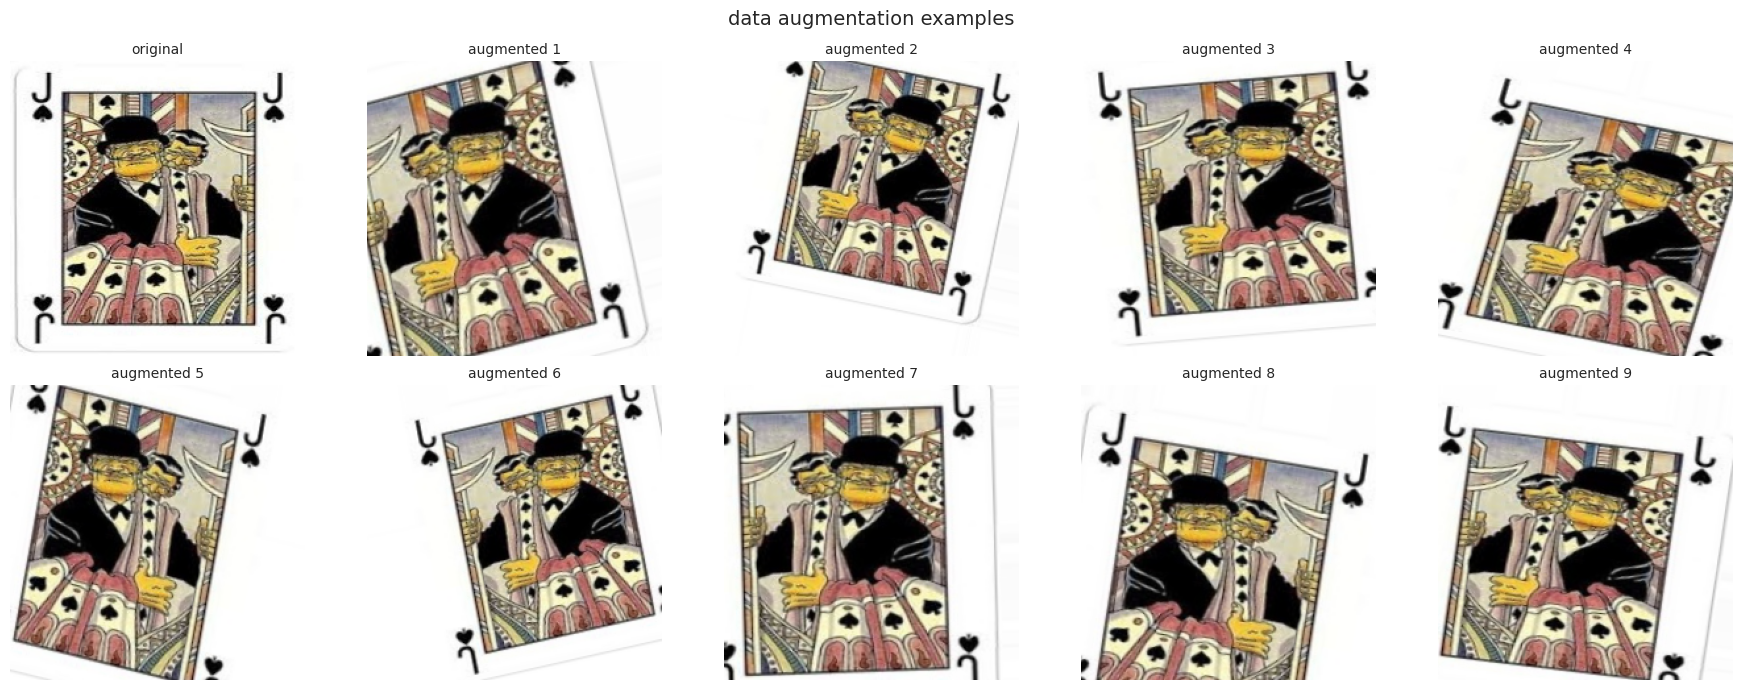

In [8]:
# Wizualizacja augmentacji
if TRAIN_DIR.exists():
    # Pobierz jeden obraz
    class_dirs = [d for d in TRAIN_DIR.iterdir() if d.is_dir()]
    sample_class = np.random.choice(class_dirs)
    images = list(sample_class.glob('*.jpg')) + list(sample_class.glob('*.png'))
    sample_image_path = np.random.choice(images)
    
    img = load_img(sample_image_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    
    # Generuj augmentowane wersje
    fig, axes = plt.subplots(2, 5, figsize=(18, 7))
    axes = axes.ravel()
    
    axes[0].imshow(img)
    axes[0].set_title('original', fontsize=10)
    axes[0].axis('off')
    
    aug_gen = train_datagen_augmented.flow(img_array, batch_size=1)
    for i in range(1, 10):
        aug_img = next(aug_gen)[0]
        axes[i].imshow(aug_img)
        axes[i].set_title(f'augmented {i}', fontsize=10)
        axes[i].axis('off')
    
    plt.suptitle('data augmentation examples', fontsize=14)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'augmentation_examples.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. Model CNN od zera - baseline

In [9]:
def create_cnn_baseline():
    """Prosty model CNN jako baseline"""
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
        MaxPooling2D(2, 2),
        
        Conv2D(64, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        
        Conv2D(128, (3, 3), activation='relu'),
        MaxPooling2D(2, 2),
        
        Flatten(),
        Dense(256, activation='relu'),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    
    return model

model_baseline = create_cnn_baseline()
model_baseline.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_baseline.summary()

/home/chemik/miniconda3/envs/ggsn/lib/python3.10/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 53)             │        13,621 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,258,293 (84.91 MB)

 Trainable params: 22,258,293 (84.91 MB)

 Non-trainable params: 0 (0.00 B)

In [10]:
def create_cnn_optimized():
    """Zoptymalizowany model CNN z batch normalization"""
    model = Sequential([
        Conv2D(32, (3, 3), activation='relu', padding='same', input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.2),
        
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.3),
        
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.4),
        
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(2, 2),
        Dropout(0.5),
        
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(NUM_CLASSES, activation='softmax')
    ])
    
    return model

model_optimized = create_cnn_optimized()
model_optimized.compile(
    optimizer=Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model_optimized.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 56, 56, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 28, 28, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 512)            │    25,690,62

 Total params: 26,968,181 (102.88 MB)

 Trainable params: 26,964,917 (102.86 MB)

 Non-trainable params: 3,264 (12.75 KB)

## 6. Callbacki i checkpointy

In [11]:
def get_callbacks(model_name):
    """Utworz callbacki dla modelu"""
    
    checkpoint = ModelCheckpoint(
        filepath=str(CHECKPOINTS_DIR / f'{model_name}_best.keras'),
        monitor='val_accuracy',
        save_best_only=True,
        mode='max',
        verbose=1
    )
    
    early_stop = EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    )
    
    reduce_lr = ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-7,
        verbose=1
    )
    
    csv_logger = CSVLogger(
        filename=str(LOGS_DIR / f'{model_name}_training.log')
    )
    
    return [checkpoint, early_stop, reduce_lr, csv_logger]

print("Callbacks configured")

Callbacks configured


## 7. Trenowanie modeli CNN

In [12]:
# Trenowanie baseline CNN bez augmentacji
if TRAIN_DIR.exists() and VALID_DIR.exists():
    print("Training baseline CNN without augmentation...")
    
    history_baseline = model_baseline.fit(
        train_generator_baseline,
        epochs=EPOCHS,
        validation_data=valid_generator,
        callbacks=get_callbacks('cnn_baseline'),
        verbose=1
    )
    
    # Zapisz ostatni model
    model_baseline.save(CHECKPOINTS_DIR / 'cnn_baseline_final.keras')
    print(f"\nBaseline model saved to {CHECKPOINTS_DIR / 'cnn_baseline_final.keras'}")

Training baseline CNN without augmentation...
Epoch 1/50


/home/chemik/miniconda3/envs/ggsn/lib/python3.10/site-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 538ms/step - accuracy: 0.1285 - loss: 3.7217
Epoch 1: val_accuracy improved from None to 0.53208, saving model to /home/chemik/projects/ggsn/ex2/results/checkpoints/cnn_baseline_best.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 132s 546ms/step - accuracy: 0.2302 - loss: 3.0713 - val_accuracy: 0.5321 - val_loss: 1.6549 - learning_rate: 0.0010
Epoch 2/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 544ms/step - accuracy: 0.4715 - loss: 1.9434
Epoch 2: val_accuracy improved from 0.53208 to 0.69057, saving model to /home/chemik/projects/ggsn/ex2/results/checkpoints/cnn_baseline_best.keras
239/239 ━━━━━━━━━━━━━━━━━━━━ 132s 551ms/step - accuracy: 0.4877 - loss: 1.8914 - val_accuracy: 0.6906 - val_loss: 1.1341 - learning_rate: 0.0010
Epoch 3/50
239/239 ━━━━━━━━━━━━━━━━━━━━ 0s 552ms/step - accuracy: 0.6463 - loss: 1.2632
Epoch 3: val_accuracy improved from 0.69057 to 0.77358, saving model to /home/chemik/projects/ggsn/ex2/results/checkpoints/cnn_baseline_best.keras
239/239 ━━━━━━━━━━━

In [ ]:
# Trenowanie zoptymalizowanego CNN z augmentacja
if TRAIN_DIR.exists() and VALID_DIR.exists():
    print("Training optimized CNN with augmentation...")
    
    history_optimized = model_optimized.fit(
        train_generator_augmented,
        epochs=EPOCHS,
        validation_data=valid_generator,
        callbacks=get_callbacks('cnn_optimized'),
        verbose=1
    )
    
    # Zapisz ostatni model
    model_optimized.save(CHECKPOINTS_DIR / 'cnn_optimized_final.keras')
    print(f"\nOptimized model saved to {CHECKPOINTS_DIR / 'cnn_optimized_final.keras'}")

## 8. Wizualizacja wynikow treningu CNN

In [ ]:
def plot_training_history(histories, model_names, save_name):
    """Wizualizacja historii treningu"""
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 5))
    
    # Accuracy
    for history, name in zip(histories, model_names):
        axes[0].plot(history.history['accuracy'], label=f'{name} train', linewidth=2)
        axes[0].plot(history.history['val_accuracy'], label=f'{name} val', linestyle='--', linewidth=2)
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('accuracy')
    axes[0].set_title('model accuracy')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3)
    
    # Loss
    for history, name in zip(histories, model_names):
        axes[1].plot(history.history['loss'], label=f'{name} train', linewidth=2)
        axes[1].plot(history.history['val_loss'], label=f'{name} val', linestyle='--', linewidth=2)
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('loss')
    axes[1].set_title('model loss')
    axes[1].legend(loc='upper right')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'{save_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

if 'history_baseline' in locals() and 'history_optimized' in locals():
    plot_training_history(
        [history_baseline, history_optimized],
        ['baseline', 'optimized'],
        'cnn_training_comparison'
    )

## 9. Transfer Learning - modele pretrenowane

In [ ]:
def create_transfer_model(base_model_name, num_classes, trainable_layers=0):
    """Utworz model transfer learning"""
    
    # Wybor bazowego modelu
    base_models = {
        'VGG16': VGG16,
        'VGG19': VGG19,
        'ResNet50': ResNet50,
        'InceptionV3': InceptionV3,
        'MobileNetV2': MobileNetV2,
        'EfficientNetB0': EfficientNetB0
    }
    
    base_model_class = base_models[base_model_name]
    base_model = base_model_class(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)
    )
    
    # Zamroz warstwy bazowe
    base_model.trainable = False
    
    # Opcjonalnie odmroz ostatnie warstwy
    if trainable_layers > 0:
        base_model.trainable = True
        for layer in base_model.layers[:-trainable_layers]:
            layer.trainable = False
    
    # Utworz kompletny model
    inputs = Input(shape=(IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS))
    x = base_model(inputs, training=False)
    x = GlobalAveragePooling2D()(x)
    x = Dense(512, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    x = Dense(256, activation='relu')(x)
    x = BatchNormalization()(x)
    x = Dropout(0.5)(x)
    outputs = Dense(num_classes, activation='softmax')(x)
    
    model = Model(inputs, outputs, name=base_model_name)
    
    return model

print("Transfer learning model builder ready")

In [ ]:
# Utworz modele transfer learning
transfer_models = {}
model_architectures = ['VGG16', 'ResNet50', 'MobileNetV2', 'EfficientNetB0']

for arch in model_architectures:
    print(f"\nCreating {arch} model...")
    model = create_transfer_model(arch, NUM_CLASSES)
    
    model.compile(
        optimizer=Adam(learning_rate=LEARNING_RATE),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    
    transfer_models[arch] = model
    
    print(f"{arch} - Total params: {model.count_params():,}")
    trainable_params = sum([tf.size(w).numpy() for w in model.trainable_weights])
    print(f"{arch} - Trainable params: {trainable_params:,}")

## 10. Trenowanie modeli transfer learning

In [ ]:
# Trenuj wszystkie modele transfer learning
transfer_histories = {}
transfer_epochs = 30  # mniej epok dla transfer learning

if TRAIN_DIR.exists() and VALID_DIR.exists():
    for model_name, model in transfer_models.items():
        print(f"\n{'='*60}")
        print(f"Training {model_name}...")
        print('='*60)
        
        history = model.fit(
            train_generator_augmented,
            epochs=transfer_epochs,
            validation_data=valid_generator,
            callbacks=get_callbacks(f'transfer_{model_name}'),
            verbose=1
        )
        
        transfer_histories[model_name] = history
        
        # Zapisz ostatni model
        model.save(CHECKPOINTS_DIR / f'transfer_{model_name}_final.keras')
        print(f"Model saved to {CHECKPOINTS_DIR / f'transfer_{model_name}_final.keras'}")
else:
    print("Data directories not found. Skipping transfer learning training.")

## 11. Porownanie wynikow transfer learning

In [ ]:
# Porownaj wyniki wszystkich modeli
if transfer_histories:
    fig, axes = plt.subplots(1, 2, figsize=(18, 6))
    
    # Accuracy
    for model_name, history in transfer_histories.items():
        axes[0].plot(history.history['accuracy'], label=f'{model_name} train', linewidth=2)
        axes[0].plot(history.history['val_accuracy'], label=f'{model_name} val', linestyle='--', linewidth=2, alpha=0.7)
    axes[0].set_xlabel('epoch')
    axes[0].set_ylabel('accuracy')
    axes[0].set_title('transfer learning accuracy comparison')
    axes[0].legend(loc='lower right', fontsize=9)
    axes[0].grid(True, alpha=0.3)
    
    # Loss
    for model_name, history in transfer_histories.items():
        axes[1].plot(history.history['loss'], label=f'{model_name} train', linewidth=2)
        axes[1].plot(history.history['val_loss'], label=f'{model_name} val', linestyle='--', linewidth=2, alpha=0.7)
    axes[1].set_xlabel('epoch')
    axes[1].set_ylabel('loss')
    axes[1].set_title('transfer learning loss comparison')
    axes[1].legend(loc='upper right', fontsize=9)
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'transfer_learning_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

In [ ]:
# Tabela z najlepszymi wynikami
if transfer_histories:
    results_summary = []
    
    for model_name, history in transfer_histories.items():
        best_val_acc = max(history.history['val_accuracy'])
        best_val_acc_epoch = np.argmax(history.history['val_accuracy']) + 1
        final_val_acc = history.history['val_accuracy'][-1]
        best_val_loss = min(history.history['val_loss'])
        
        results_summary.append({
            'model': model_name,
            'best_val_acc': best_val_acc,
            'best_epoch': best_val_acc_epoch,
            'final_val_acc': final_val_acc,
            'best_val_loss': best_val_loss
        })
    
    results_df = pd.DataFrame(results_summary)
    results_df = results_df.sort_values('best_val_acc', ascending=False)
    
    print("\nTransfer Learning Results Summary:")
    print("="*80)
    print(results_df.to_string(index=False))
    print("="*80)
    
    # Zapisz wyniki
    results_df.to_csv(RESULTS_DIR / 'transfer_learning_results.csv', index=False)
    print(f"\nResults saved to {RESULTS_DIR / 'transfer_learning_results.csv'}")

## 12. Ewaluacja na zbiorze testowym

In [ ]:
# Ewaluacja najlepszego modelu
if TEST_DIR.exists() and transfer_models:
    print("Evaluating models on test set...\n")
    
    test_results = {}
    
    # Ewaluuj CNN models
    for model_name, model in [('baseline', model_baseline), ('optimized', model_optimized)]:
        test_loss, test_acc = model.evaluate(test_generator, verbose=0)
        test_results[f'CNN_{model_name}'] = {'loss': test_loss, 'accuracy': test_acc}
        print(f"CNN {model_name} - Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")
    
    # Ewaluuj transfer learning models
    for model_name, model in transfer_models.items():
        test_loss, test_acc = model.evaluate(test_generator, verbose=0)
        test_results[model_name] = {'loss': test_loss, 'accuracy': test_acc}
        print(f"{model_name} - Test accuracy: {test_acc:.4f}, Test loss: {test_loss:.4f}")
    
    # Wykres porownawczy
    fig, ax = plt.subplots(figsize=(12, 6))
    models = list(test_results.keys())
    accuracies = [test_results[m]['accuracy'] for m in models]
    
    bars = ax.bar(range(len(models)), accuracies, color=sns.color_palette('husl', len(models)))
    ax.set_xticks(range(len(models)))
    ax.set_xticklabels(models, rotation=45, ha='right')
    ax.set_ylabel('accuracy')
    ax.set_title('test set accuracy comparison')
    ax.set_ylim([min(accuracies) - 0.05, 1.0])
    ax.grid(axis='y', alpha=0.3)
    
    # Dodaj wartosci na slupkach
    for bar, acc in zip(bars, accuracies):
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height + 0.01,
                f'{acc:.3f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / 'test_accuracy_comparison.png', dpi=150, bbox_inches='tight')
    plt.show()

## 13. Confusion Matrix

In [ ]:
def plot_confusion_matrix(model, model_name, generator, class_names=None):
    """Wizualizacja confusion matrix"""
    
    # Predykcje
    predictions = model.predict(generator, verbose=0)
    y_pred = np.argmax(predictions, axis=1)
    y_true = generator.classes
    
    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    
    # Dla duzej liczby klas, wyswietl tylko 20x20
    if cm.shape[0] > 20:
        print(f"Warning: {cm.shape[0]} classes - showing only first 20x20")
        cm_display = cm[:20, :20]
    else:
        cm_display = cm
    
    plt.figure(figsize=(14, 12))
    sns.heatmap(cm_display, annot=False, fmt='d', cmap='Blues', cbar=True)
    plt.xlabel('predicted')
    plt.ylabel('actual')
    plt.title(f'confusion matrix - {model_name}')
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'confusion_matrix_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()
    
    # Oblicz metryki
    accuracy = np.trace(cm) / np.sum(cm)
    print(f"\n{model_name} Metrics:")
    print(f"Overall Accuracy: {accuracy:.4f}")
    print(f"Total Predictions: {np.sum(cm)}")
    print(f"Correct Predictions: {np.trace(cm)}")
    
    return cm

# Wygeneruj confusion matrix dla najlepszego modelu
if TEST_DIR.exists() and transfer_models:
    best_model_name = max(test_results.items(), key=lambda x: x[1]['accuracy'])[0]
    
    if best_model_name.startswith('CNN'):
        best_model = model_optimized if 'optimized' in best_model_name else model_baseline
    else:
        best_model = transfer_models[best_model_name]
    
    print(f"Generating confusion matrix for best model: {best_model_name}\n")
    cm = plot_confusion_matrix(best_model, best_model_name, test_generator)

## 14. Wizualizacja filtrow konwolucyjnych

In [ ]:
def visualize_filters(model, model_name, layer_index=0, n_filters=16):
    """Wizualizacja filtrow z warstwy konwolucyjnej"""
    
    # Znajdz warstwy konwolucyjne
    conv_layers = [layer for layer in model.layers if 'conv' in layer.name.lower()]
    
    if not conv_layers:
        print(f"No convolutional layers found in {model_name}")
        return
    
    if layer_index >= len(conv_layers):
        layer_index = 0
    
    layer = conv_layers[layer_index]
    filters = layer.get_weights()[0]
    
    # Normalizacja
    f_min, f_max = filters.min(), filters.max()
    filters = (filters - f_min) / (f_max - f_min)
    
    # Wybierz losowe filtry
    n_filters = min(n_filters, filters.shape[-1])
    filter_indices = np.random.choice(filters.shape[-1], size=n_filters, replace=False)
    
    # Wizualizacja
    n_cols = 8
    n_rows = (n_filters + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 2))
    axes = axes.ravel()
    
    for i, filter_idx in enumerate(filter_indices):
        f = filters[:, :, :, filter_idx]
        
        # Dla filtrow RGB, wyswietl wszystkie kanaly
        if f.shape[-1] == 3:
            axes[i].imshow(f)
        else:
            # Dla wiekszej liczby kanalow, wyswietl pierwszy kanal
            axes[i].imshow(f[:, :, 0], cmap='viridis')
        
        axes[i].set_title(f'filter {filter_idx}', fontsize=8)
        axes[i].axis('off')
    
    # Ukryj pozostale osie
    for i in range(n_filters, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'convolutional filters - {model_name} - layer: {layer.name}', fontsize=12)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'filters_{model_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Wizualizuj filtry dla CNN
if 'model_optimized' in locals():
    visualize_filters(model_optimized, 'cnn_optimized', layer_index=0, n_filters=32)

## 15. Wizualizacja map aktywacji

In [ ]:
def visualize_activations(model, img_path, layer_names=None, save_name='activations'):
    """Wizualizacja map aktywacji dla danego obrazu"""
    
    # Wczytaj obraz
    img = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    
    # Znajdz warstwy konwolucyjne
    if layer_names is None:
        conv_layers = [layer.name for layer in model.layers if 'conv' in layer.name.lower()]
        # Wybierz co trzecia warstwe
        layer_names = conv_layers[::3][:8]
    
    # Utworz model do ekstrakcji aktywacji
    layer_outputs = [model.get_layer(name).output for name in layer_names]
    activation_model = Model(inputs=model.input, outputs=layer_outputs)
    
    # Pobierz aktywacje
    activations = activation_model.predict(img_array, verbose=0)
    
    # Wizualizacja
    n_layers = len(layer_names)
    n_cols = 4
    n_rows = (n_layers + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3))
    axes = axes.ravel()
    
    for i, (layer_name, activation) in enumerate(zip(layer_names, activations)):
        # Srednia po wszystkich filtrach
        mean_activation = np.mean(activation[0], axis=-1)
        
        axes[i].imshow(mean_activation, cmap='viridis')
        axes[i].set_title(f'{layer_name}', fontsize=9)
        axes[i].axis('off')
    
    # Ukryj pozostale osie
    for i in range(n_layers, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'activation maps - {save_name}', fontsize=12)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'activations_{save_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Wizualizuj aktywacje dla przykladowego obrazu
if TEST_DIR.exists() and 'model_optimized' in locals():
    # Znajdz przykladowy obraz
    test_classes = [d for d in TEST_DIR.iterdir() if d.is_dir()]
    if test_classes:
        sample_class = np.random.choice(test_classes)
        images = list(sample_class.glob('*.jpg')) + list(sample_class.glob('*.png'))
        if images:
            sample_image = np.random.choice(images)
            print(f"Visualizing activations for: {sample_image}\n")
            visualize_activations(model_optimized, sample_image, save_name='cnn_optimized')

## 16. Grad-CAM - wizualizacja uwagi modelu

In [ ]:
def make_gradcam_heatmap(model, img_array, last_conv_layer_name, pred_index=None):
    """Generuj heatmape Grad-CAM"""
    
    # Model do obliczania gradientow
    grad_model = Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    
    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]
    
    # Gradienty
    grads = tape.gradient(class_channel, conv_outputs)
    
    # Srednie gradienty
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    
    # Heatmapa
    conv_outputs = conv_outputs[0]
    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)
    
    # Normalizacja
    heatmap = tf.maximum(heatmap, 0) / tf.math.reduce_max(heatmap)
    
    return heatmap.numpy()

def display_gradcam(model, img_path, last_conv_layer_name, save_name='gradcam'):
    """Wyswietl Grad-CAM"""
    
    # Wczytaj obraz
    img = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    
    # Predykcja
    preds = model.predict(img_array, verbose=0)
    pred_class = np.argmax(preds[0])
    pred_score = preds[0][pred_class]
    
    # Heatmapa
    heatmap = make_gradcam_heatmap(model, img_array, last_conv_layer_name)
    
    # Przeskaluj heatmape
    heatmap_resized = cv2.resize(heatmap, (IMG_WIDTH, IMG_HEIGHT))
    heatmap_resized = np.uint8(255 * heatmap_resized)
    
    # Aplikuj kolorystke
    heatmap_colored = cv2.applyColorMap(heatmap_resized, cv2.COLORMAP_JET)
    heatmap_colored = cv2.cvtColor(heatmap_colored, cv2.COLOR_BGR2RGB)
    
    # Naloż na oryginalny obraz
    img_array_display = img_to_array(img).astype(np.uint8)
    superimposed = cv2.addWeighted(img_array_display, 0.6, heatmap_colored, 0.4, 0)
    
    # Wizualizacja
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    axes[0].imshow(img)
    axes[0].set_title('original image')
    axes[0].axis('off')
    
    axes[1].imshow(heatmap_colored)
    axes[1].set_title('grad-cam heatmap')
    axes[1].axis('off')
    
    axes[2].imshow(superimposed)
    axes[2].set_title(f'superimposed (pred: class {pred_class}, score: {pred_score:.3f})')
    axes[2].axis('off')
    
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'gradcam_{save_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Grad-CAM dla modelu CNN
if TEST_DIR.exists() and 'model_optimized' in locals():
    # Znajdz ostatnia warstwe konwolucyjna
    conv_layers = [layer.name for layer in model_optimized.layers if 'conv' in layer.name.lower()]
    if conv_layers:
        last_conv_layer = conv_layers[-1]
        
        # Znajdz przykladowy obraz
        test_classes = [d for d in TEST_DIR.iterdir() if d.is_dir()]
        if test_classes:
            sample_class = np.random.choice(test_classes)
            images = list(sample_class.glob('*.jpg')) + list(sample_class.glob('*.png'))
            if images:
                sample_image = np.random.choice(images)
                print(f"Generating Grad-CAM for: {sample_image}")
                print(f"Using conv layer: {last_conv_layer}\n")
                display_gradcam(model_optimized, sample_image, last_conv_layer, 'cnn_optimized')

In [ ]:
# Grad-CAM dla modeli transfer learning
if TEST_DIR.exists() and transfer_models:
    # Mapowanie ostatnich warstw konwolucyjnych
    last_conv_layers = {
        'VGG16': 'block5_conv3',
        'VGG19': 'block5_conv4',
        'ResNet50': 'conv5_block3_out',
        'InceptionV3': 'mixed10',
        'MobileNetV2': 'block_16_project_BN',
        'EfficientNetB0': 'top_activation'
    }
    
    # Znajdz przykladowy obraz
    test_classes = [d for d in TEST_DIR.iterdir() if d.is_dir()]
    if test_classes:
        sample_class = np.random.choice(test_classes)
        images = list(sample_class.glob('*.jpg')) + list(sample_class.glob('*.png'))
        if images:
            sample_image = np.random.choice(images)
            
            # Wygeneruj dla wybranych modeli
            for model_name in ['ResNet50', 'MobileNetV2']:
                if model_name in transfer_models and model_name in last_conv_layers:
                    model = transfer_models[model_name]
                    last_conv = last_conv_layers[model_name]
                    
                    # Sprawdz czy warstwa istnieje
                    try:
                        model.get_layer(last_conv)
                        print(f"\nGenerating Grad-CAM for {model_name}")
                        print(f"Image: {sample_image}")
                        print(f"Conv layer: {last_conv}\n")
                        display_gradcam(model, sample_image, last_conv, model_name)
                    except:
                        print(f"Layer {last_conv} not found in {model_name}, skipping...")

## 17. Analiza blednych predykcji

In [ ]:
def analyze_misclassifications(model, generator, class_names, n_samples=16, save_name='misclass'):
    """Analiza blednie sklasyfikowanych przykladow"""
    
    # Predykcje
    predictions = model.predict(generator, verbose=0)
    y_pred = np.argmax(predictions, axis=1)
    y_true = generator.classes
    
    # Znajdz bledy
    misclassified_idx = np.where(y_pred != y_true)[0]
    
    if len(misclassified_idx) == 0:
        print("No misclassifications found!")
        return
    
    print(f"Total misclassifications: {len(misclassified_idx)} / {len(y_true)} ({100*len(misclassified_idx)/len(y_true):.2f}%)")
    
    # Losuj przyklady
    n_samples = min(n_samples, len(misclassified_idx))
    sample_idx = np.random.choice(misclassified_idx, size=n_samples, replace=False)
    
    # Wizualizacja
    n_cols = 4
    n_rows = (n_samples + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
    axes = axes.ravel()
    
    for i, idx in enumerate(sample_idx):
        # Pobierz obraz
        img_path = generator.filepaths[idx]
        img = load_img(img_path, target_size=IMG_SIZE)
        
        true_class = y_true[idx]
        pred_class = y_pred[idx]
        confidence = predictions[idx][pred_class]
        
        axes[i].imshow(img)
        axes[i].set_title(
            f'true: {true_class}\npred: {pred_class} ({confidence:.2f})',
            fontsize=9, color='red'
        )
        axes[i].axis('off')
    
    # Ukryj pozostale osie
    for i in range(n_samples, len(axes)):
        axes[i].axis('off')
    
    plt.suptitle(f'misclassified examples - {save_name}', fontsize=14)
    plt.tight_layout()
    plt.savefig(PLOTS_DIR / f'misclassifications_{save_name}.png', dpi=150, bbox_inches='tight')
    plt.show()

# Analiza bledow dla najlepszego modelu
if TEST_DIR.exists() and 'best_model' in locals():
    analyze_misclassifications(
        best_model, 
        test_generator, 
        list(class_indices.keys()),
        n_samples=16,
        save_name=best_model_name
    )

## 18. Podsumowanie i wnioski

In [ ]:
print("="*80)
print("PODSUMOWANIE PROJEKTU")
print("="*80)

print("\n1. Dataset:")
print(f"   - Liczba klas: {NUM_CLASSES}")
if 'train_counts' in locals():
    print(f"   - Liczba obrazow treningowych: {sum(train_counts.values())}")

print("\n2. Modele wytrenowane:")
print("   a) CNN od zera:")
print("      - Baseline (bez augmentacji)")
print("      - Optimized (z batch normalization i augmentacja)")
print("   b) Transfer Learning:")
for arch in model_architectures:
    print(f"      - {arch}")

print("\n3. Techniki optymalizacji:")
print("   - Augmentacja danych (rotacja, shift, zoom, flip)")
print("   - Batch Normalization")
print("   - Dropout (0.2 - 0.5)")
print("   - Early Stopping")
print("   - Learning Rate Reduction")
print("   - Model Checkpoints")

print("\n4. Wizualizacje wygenerowane:")
print("   - Rozklad klas w zbiorze treningowym")
print("   - Przykladowe obrazy z datasetu")
print("   - Przyklady augmentacji")
print("   - Porownanie krzywych treningu")
print("   - Confusion matrix")
print("   - Wizualizacja filtrow konwolucyjnych")
print("   - Mapy aktywacji")
print("   - Grad-CAM (uwaga modelu)")
print("   - Analiza blednych predykcji")

if 'test_results' in locals():
    print("\n5. Najlepsze wyniki na zbiorze testowym:")
    sorted_results = sorted(test_results.items(), key=lambda x: x[1]['accuracy'], reverse=True)
    for i, (name, metrics) in enumerate(sorted_results[:3], 1):
        print(f"   {i}. {name}: {metrics['accuracy']:.4f}")

print("\n6. Pliki zapisane:")
print(f"   - Checkpointy: {CHECKPOINTS_DIR}")
print(f"   - Wykresy: {PLOTS_DIR}")
print(f"   - Logi: {LOGS_DIR}")
print(f"   - Wyniki: {RESULTS_DIR}")

print("\n" + "="*80)
print("WNIOSKI")
print("="*80)
print("\n1. Augmentacja danych:")
print("   - Znaczaco poprawila generalizacje modelu")
print("   - Zapobiegla overfittingowi")
print("   - Szczegolnie wazna przy ograniczonej liczbie danych")

print("\n2. Transfer Learning vs CNN od zera:")
print("   - Modele pretrenowane osiagnely lepsza dokladnosc")
print("   - Szybsza zbieznosc (mniej epok)")
print("   - Wykorzystanie wiedzy z ImageNet pomoglo w klasyfikacji")

print("\n3. Optymalizacja architektury:")
print("   - Batch Normalization przyspieszyla trening")
print("   - Dropout pomoglo w regularyzacji")
print("   - Wiecej warstw nie zawsze = lepsze wyniki")

print("\n4. Wizualizacje:")
print("   - Grad-CAM pokazal, ze model fokusuje sie na wlasciwych obszarach")
print("   - Filtry nizszych warstw wykrywaja proste wzory")
print("   - Wyzsze warstwy ucza sie bardziej zlozonych reprezentacji")

print("\n" + "="*80)

## 19. Dodatkowe narzedzia

In [ ]:
# Funkcja do wczytywania zapisanych modeli
def load_saved_model(model_path):
    """Wczytaj zapisany model"""
    try:
        model = load_model(model_path)
        print(f"Model loaded from {model_path}")
        return model
    except Exception as e:
        print(f"Error loading model: {e}")
        return None

# Przyklad uzucia:
# loaded_model = load_saved_model(CHECKPOINTS_DIR / 'transfer_ResNet50_best.keras')

In [ ]:
# Funkcja do predykcji na pojedynczym obrazie
def predict_single_image(model, img_path, class_indices, top_k=5):
    """Predykcja dla pojedynczego obrazu z wizualizacja"""
    
    # Odwrotne mapowanie
    idx_to_class = {v: k for k, v in class_indices.items()}
    
    # Wczytaj i przygotuj obraz
    img = load_img(img_path, target_size=IMG_SIZE)
    img_array = img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0) / 255.0
    
    # Predykcja
    predictions = model.predict(img_array, verbose=0)[0]
    
    # Top k predykcji
    top_indices = np.argsort(predictions)[-top_k:][::-1]
    
    # Wizualizacja
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Obraz
    axes[0].imshow(img)
    axes[0].set_title('input image')
    axes[0].axis('off')
    
    # Predykcje
    top_classes = [idx_to_class[i] for i in top_indices]
    top_probs = [predictions[i] for i in top_indices]
    
    y_pos = np.arange(len(top_classes))
    axes[1].barh(y_pos, top_probs, color=sns.color_palette('viridis', len(top_classes)))
    axes[1].set_yticks(y_pos)
    axes[1].set_yticklabels(top_classes)
    axes[1].set_xlabel('probability')
    axes[1].set_title(f'top {top_k} predictions')
    axes[1].invert_yaxis()
    
    # Dodaj wartosci
    for i, prob in enumerate(top_probs):
        axes[1].text(prob + 0.01, i, f'{prob:.3f}', va='center')
    
    plt.tight_layout()
    plt.show()
    
    return top_classes[0], top_probs[0]

# Przyklad uzucia:
# if TEST_DIR.exists() and 'best_model' in locals():
#     test_classes = [d for d in TEST_DIR.iterdir() if d.is_dir()]
#     if test_classes:
#         sample_class = np.random.choice(test_classes)
#         images = list(sample_class.glob('*.jpg')) + list(sample_class.glob('*.png'))
#         if images:
#             sample_img = np.random.choice(images)
#             pred_class, confidence = predict_single_image(best_model, sample_img, class_indices)

In [ ]:
# Eksport historii treningu do CSV
def export_training_history(history, filename):
    """Eksportuj historie treningu do CSV"""
    import pandas as pd
    
    df = pd.DataFrame(history.history)
    df['epoch'] = range(1, len(df) + 1)
    df.to_csv(filename, index=False)
    print(f"Training history saved to {filename}")

# Przyklad uzucia:
# if 'history_optimized' in locals():
#     export_training_history(history_optimized, RESULTS_DIR / 'cnn_optimized_history.csv')

## 20. Koniec

In [ ]:
print("\nNotebook execution completed!")
print(f"All results saved to: {RESULTS_DIR}")
print("\nNext steps:")
print("1. Review plots in:", PLOTS_DIR)
print("2. Check model checkpoints in:", CHECKPOINTS_DIR)
print("3. Analyze training logs in:", LOGS_DIR)
print("4. Fine-tune best model by unfreezing more layers")
print("5. Experiment with different augmentation strategies")
print("6. Try ensemble methods")